# Notebook 06 — Model Evaluation
## Sistem CBR Putusan Kasasi Peradilan Anak ABH · Mahkamah Agung RI

Evaluasi komprehensif performa retrieval dan prediksi sistem CBR,
dilakukan **setelah** tahap Revisi & Retain (NB05) sehingga case base
yang dievaluasi adalah versi terbaru (post-retain).

**Tahap ini mencakup:**
- Evaluasi retrieval: Accuracy@k, Precision, Recall, F1 (TF-IDF vs IndoBERT vs SVM)
- Evaluasi prediksi: 4 algoritma (Majority Vote, Weighted Sim, SVM, Hybrid)
- Visualisasi performa multi-panel
- Analisis kegagalan (error analysis / rejection analysis)
- Perbandingan sebelum vs sesudah retain (jika retain_log tersedia)
- Ringkasan evaluasi & rekomendasi perbaikan

## 1 · Import & Load Data

Load semua output dari NB03, NB04, dan NB05 (retain log).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import Counter
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# ── Resolusi ROOT_DIR ───────────────────────────────────────────────
# Agar path data/ tetap valid baik notebook dijalankan dari root project
# maupun dari dalam folder notebook/ (working directory kernel kadang
# ikut lokasi file .ipynb). Cari ke atas folder yang punya subfolder data/;
# kalau belum ada (run pertama kali), fallback: naik 1 level jika cwd = "notebook".
def _tentukan_root_dir() -> Path:
    cwd = Path.cwd().resolve()
    p = cwd
    for _ in range(4):
        if (p / "data").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    return cwd.parent if cwd.name.lower() in ("notebook", "notebooks") else cwd

ROOT_DIR = _tentukan_root_dir()

DATA_DIR = ROOT_DIR / 'data'
EVAL_DIR    = ROOT_DIR / 'data' / 'eval'
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR   = ROOT_DIR / 'data' / 'results'
EVAL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR = ROOT_DIR / 'data' / 'eval' / 'metrics'
VIZ_DIR     = ROOT_DIR / 'data' / 'eval' / 'visualisasi'
METRICS_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# ── Load semua data yang diperlukan ───────────────────────────────────
with open(PROCESSED_DIR / 'case_base.json', encoding='utf-8') as f:
    case_base = json.load(f)
df = pd.DataFrame(case_base)

with open(PROCESSED_DIR / 'retrieval_results.json', encoding='utf-8') as f:
    retrieval_results = json.load(f)

df_pred = pd.read_csv(RESULTS_DIR / 'predictions.csv', encoding='utf-8-sig')

with open(METRICS_DIR / 'queries.json', encoding='utf-8') as f:
    queries = json.load(f)

test_ids_path = METRICS_DIR / 'test_case_ids.json'
if test_ids_path.exists():
    with open(test_ids_path, encoding='utf-8') as f:
        test_case_ids = set(json.load(f))
    print(f'test_case_ids loaded : {len(test_case_ids)} kasus (test set 20%)')
else:
    print('[WARN] test_case_ids.json tidak ditemukan — pakai seluruh data')
    test_case_ids = set(df['case_id'].tolist())

# ── Load retain_log dari NB05 (opsional) ─────────────────────────────
retain_log_path = METRICS_DIR / 'retain_log.json'
retain_log = None
if retain_log_path.exists():
    with open(retain_log_path, encoding='utf-8') as f:
        retain_log = json.load(f)
    print(f'retain_log loaded    : iterasi {retain_log["iterasi"]}, '
          f'{retain_log["entry_ditambahkan"]} kasus ditambahkan')
else:
    print('[INFO] retain_log.json tidak ditemukan — tahap retain belum dijalankan')

print(f'Case base (post-retain) : {len(df)} kasus')
print(f'Retrieval results       : {len(retrieval_results)} entri')
print(f'Predictions             : {len(df_pred)} baris')
print(f'Query uji               : {len(queries)} query')
print()
print('Distribusi outcome kasasi (post-retain):')
print(df['outcome_kasasi'].value_counts().to_string())

test_case_ids loaded : 28 kasus (test set 20%)
retain_log loaded    : iterasi 2, 0 kasus ditambahkan
Case base (post-retain) : 150 kasus
Retrieval results       : 150 entri
Predictions             : 28 baris
Query uji               : 10 query

Distribusi outcome kasasi (post-retain):
outcome_kasasi
DITOLAK             124
TIDAK TERDETEKSI     11
DIPERBAIKI           10
DIKABULKAN            5


## 2 · Rebuild Fitur — Self-Contained

Rebuild TF-IDF dan SVM hanya pada train set, konsisten dengan NB03 & NB04.

In [2]:
def bersihkan_field(teks, max_len=None):
    # Bersihkan field dari case_base.json (konsisten dengan NB03 & NB04).
    if not teks:
        return ''
    baris = [b for b in str(teks).splitlines() if not b.startswith('#')]
    hasil = ' '.join(' '.join(baris).split())
    return hasil[:max_len] if max_len else hasil


def buat_teks_query(row):
    # Representasi teks gabungan (konsisten dengan NB03 & NB04).
    pasal        = bersihkan_field(row.get('pasal_didakwakan',  '') or '')
    memori       = bersihkan_field(row.get('memori_kasasi',     '') or '', max_len=800)
    duduk        = bersihkan_field(row.get('duduk_perkara',     '') or '', max_len=400)
    amar         = bersihkan_field(row.get('amar_putusan',      '') or '')
    vonis        = bersihkan_field(row.get('vonis',             '') or '')
    pertimbangan = bersihkan_field(row.get('pertimbangan_hukum','') or '', max_len=300)
    bagian = [pasal, memori, memori, duduk, amar, vonis, pertimbangan]
    return ' '.join(b for b in bagian if b.strip())


df['teks_query'] = df.apply(buat_teks_query, axis=1)
df_valid = df[df['outcome_kasasi'].isin(['DITOLAK','DIKABULKAN','DIPERBAIKI'])
              ].reset_index(drop=True)

X = df_valid['teks_query'].to_numpy(dtype=str)
y = df_valid['outcome_kasasi'].to_numpy(dtype=str)

kelas_counts  = df_valid['outcome_kasasi'].value_counts()
bisa_stratify = (kelas_counts >= 2).all()

# Split 80:20 dengan random_state=42 — IDENTIK dengan NB03 & NB04
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=(y if bisa_stratify else None),
)

# SVM dilatih hanya pada train set — konsisten dengan NB04 pipe_svm_eval
# Ini memastikan evaluasi SVM di NB05 tidak mengalami data leakage
pipe_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
    ('svm',   SVC(kernel='linear', C=1.0, probability=True,
                  random_state=42, class_weight='balanced')),
])
pipe_svm.fit(X_train, y_train)
y_svm_pred = pipe_svm.predict(X_test)
y_svm_true = y_test

print(f'df_valid      : {len(df_valid)} kasus')
print(f'Train/Test    : {len(X_train)} / {len(X_test)}')
print(f'SVM rebuilt   : train-only (konsisten dengan NB04 pipe_svm_eval)')
print(f'SVM test acc  : {accuracy_score(y_svm_true, y_svm_pred):.4f}')
print()
print('Catatan: SVM tidak menghasilkan ranked list, sehingga:')
print('  Acc@1 = Accuracy biasa (prediksi tunggal)')
print('  Acc@3 dan Acc@5 = N/A (tidak berlaku untuk klasifikasi langsung)')

df_valid      : 139 kasus
Train/Test    : 111 / 28
SVM rebuilt   : train-only (konsisten dengan NB04 pipe_svm_eval)
SVM test acc  : 0.9286

Catatan: SVM tidak menghasilkan ranked list, sehingga:
  Acc@1 = Accuracy biasa (prediksi tunggal)
  Acc@3 dan Acc@5 = N/A (tidak berlaku untuk klasifikasi langsung)


## 3 · [Poin f.i] Fungsi `eval_retrieval()`

Implementasi sesuai spesifikasi brief:
```python
def eval_retrieval(queries, ground_truth, k):
    # loop setiap query → hitung metrics
```

In [3]:
def eval_retrieval(retrieval_data: list, metode: str = 'bert', k: int = 5) -> dict:
    # Evaluasi retrieval pada test set (80:20 split dari NB03).
    #
    # Parameters
    # ----------
    # retrieval_data : list[dict] — isi retrieval_results.json
    # metode         : str — 'tfidf' atau 'bert'
    # k              : int — panjang top-k yang dievaluasi
    #
    # Returns
    # -------
    # dict — metrik lengkap: Acc@1, Acc@3, Acc@5, Precision, Recall, F1
    key = f'top5_{metode}'
    y_true, y_pred_at1 = [], []
    benar_at1 = benar_at3 = benar_at5 = 0
    total = 0

    for entry in retrieval_data:
        gt  = entry['outcome_kasasi']
        cid = entry['case_id']

        # Hanya evaluasi kasus di test set dengan label valid
        if cid not in test_case_ids:
            continue
        if gt == 'TIDAK TERDETEKSI':
            continue

        top_k    = entry.get(key, [])[:k]
        outcomes = [r['outcome_kasasi'] for r in top_k
                    if r['outcome_kasasi'] != 'TIDAK TERDETEKSI']

        total += 1
        if outcomes and outcomes[0] == gt: benar_at1 += 1
        if gt in outcomes[:3]:             benar_at3 += 1
        if gt in outcomes[:5]:             benar_at5 += 1

        y_true.append(gt)
        y_pred_at1.append(outcomes[0] if outcomes else 'TIDAK TERDETEKSI')

    if total == 0:
        print(f'[WARN] Tidak ada data test set untuk metode {metode}')
        return {}

    labels = sorted(set(y_true))
    return {
        'metode'    : metode.upper(),
        'total'     : total,
        'acc@1'     : round(benar_at1 / total, 4),
        'acc@3'     : round(benar_at3 / total, 4),
        'acc@5'     : round(benar_at5 / total, 4),
        'precision' : round(precision_score(y_true, y_pred_at1, average='weighted',
                                            labels=labels, zero_division=0), 4),
        'recall'    : round(recall_score(y_true, y_pred_at1, average='weighted',
                                         labels=labels, zero_division=0), 4),
        'f1'        : round(f1_score(y_true, y_pred_at1, average='weighted',
                                     labels=labels, zero_division=0), 4),
        'y_true'    : y_true,
        'y_pred'    : y_pred_at1,
    }


print('eval_retrieval() siap.')

eval_retrieval() siap.


## 4 · [Poin f.i] Evaluasi Retrieval — TF-IDF vs IndoBERT vs SVM

In [4]:
# ── TF-IDF retrieval ─────────────────────────────────────────────────
print('Mengevaluasi TF-IDF retrieval ...')
eval_tfidf = eval_retrieval(retrieval_results, metode='tfidf', k=5)

# ── IndoBERT retrieval ────────────────────────────────────────────────
print('Mengevaluasi IndoBERT retrieval ...')
eval_bert  = eval_retrieval(retrieval_results, metode='bert',  k=5)

# ── SVM klasifikasi langsung (pada test set, train-only model) ────────
# Catatan: SVM menghasilkan prediksi tunggal (bukan ranked list),
# sehingga Acc@3 dan Acc@5 tidak berlaku — hanya Acc@1 (= Accuracy).
# SVM di sini menggunakan model yang hanya dilatih pada train set (identik
# dengan pipe_svm_eval di NB04) agar evaluasi tidak ada data leakage.
eval_svm = {
    'metode'    : 'SVM (TF-IDF, balanced, train-only)',
    'total'     : len(y_svm_true),
    'acc@1'     : round(accuracy_score(y_svm_true, y_svm_pred), 4),
    'acc@3'     : 'N/A (klasifikasi langsung)',
    'acc@5'     : 'N/A (klasifikasi langsung)',
    'precision' : round(precision_score(y_svm_true, y_svm_pred,
                        average='weighted', zero_division=0), 4),
    'recall'    : round(recall_score(y_svm_true, y_svm_pred,
                        average='weighted', zero_division=0), 4),
    'f1'        : round(f1_score(y_svm_true, y_svm_pred,
                        average='weighted', zero_division=0), 4),
    'y_true'    : list(y_svm_true),
    'y_pred'    : list(y_svm_pred),
}

# ── Tabel ringkas ─────────────────────────────────────────────────────
rows = [
    {
        'Model'     : e['metode'],
        'Total'     : e['total'],
        'Acc@1'     : e['acc@1'],
        'Acc@3'     : e['acc@3'],
        'Acc@5'     : e['acc@5'],
        'Precision' : e['precision'],
        'Recall'    : e['recall'],
        'F1-Score'  : e['f1'],
    }
    for e in [eval_tfidf, eval_bert, eval_svm]
]
df_retrieval_metrics = pd.DataFrame(rows)

print(f'=== Tabel Metrik Retrieval — Test Set {len(test_case_ids)} kasus (20%) ===')
display(df_retrieval_metrics)

print('=== Classification Report: TF-IDF ===')
print(classification_report(eval_tfidf['y_true'], eval_tfidf['y_pred'], zero_division=0))
print('=== Classification Report: IndoBERT ===')
print(classification_report(eval_bert['y_true'],  eval_bert['y_pred'],  zero_division=0))
print('=== Classification Report: SVM (train-only) ===')
print(classification_report(eval_svm['y_true'], eval_svm['y_pred'], zero_division=0))

Mengevaluasi TF-IDF retrieval ...
Mengevaluasi IndoBERT retrieval ...
=== Tabel Metrik Retrieval — Test Set 28 kasus (20%) ===


,Model,Total,Acc@1,Acc@3,Acc@5,Precision,Recall,F1-Score
0,TFIDF,28,0.8571,0.9643,0.9643,0.8571,0.8571,0.8571
1,BERT,28,0.8571,0.9286,0.9643,0.8571,0.8571,0.8571
2,"SVM (TF-IDF, balanced, train-only)",28,0.9286,N/A (klasifikasi langsung),N/A (klasifikasi langsung),0.8624,0.9286,0.8942


=== Classification Report: TF-IDF ===
              precision    recall  f1-score   support

  DIKABULKAN       1.00      1.00      1.00         1
  DIPERBAIKI       0.00      0.00      0.00         2
     DITOLAK       0.92      0.92      0.92        25

    accuracy                           0.86        28
   macro avg       0.64      0.64      0.64        28
weighted avg       0.86      0.86      0.86        28

=== Classification Report: IndoBERT ===
              precision    recall  f1-score   support

  DIKABULKAN       1.00      1.00      1.00         1
  DIPERBAIKI       0.00      0.00      0.00         2
     DITOLAK       0.92      0.92      0.92        25

    accuracy                           0.86        28
   macro avg       0.64      0.64      0.64        28
weighted avg       0.86      0.86      0.86        28

=== Classification Report: SVM (train-only) ===
              precision    recall  f1-score   support

  DIKABULKAN       1.00      1.00      1.00         1
  D

### 4a · Simpan `retrieval_metrics.csv`

In [5]:
retrieval_path = METRICS_DIR / 'retrieval_metrics.csv'
df_retrieval_metrics.to_csv(retrieval_path, index=False, encoding='utf-8-sig')
print(f'Disimpan -> {retrieval_path}')

Disimpan -> D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\data\eval\metrics\retrieval_metrics.csv


## 5 · [Poin f.i] Evaluasi Prediksi — 4 Algoritma

Metrik dihitung dari `predictions.csv` yang berisi hasil 4 algoritma: Majority Vote, Weighted Similarity, SVM (train-only), dan Hybrid BERT+SVM.

In [6]:
df_p = df_pred[df_pred['ground_truth'].isin(
    ['DITOLAK', 'DIKABULKAN', 'DIPERBAIKI']
)].copy()

y_true_p = df_p['ground_truth'].tolist()

# Deteksi kolom yang tersedia (backward compatible)
has_vote   = 'predicted_outcome_vote'   in df_p.columns
has_weight = 'predicted_outcome_weight' in df_p.columns
has_svm    = 'predicted_outcome_svm'    in df_p.columns
has_hybrid = 'predicted_outcome_hybrid' in df_p.columns

y_vote   = df_p['predicted_outcome_vote'].tolist()   if has_vote   else []
y_weight = df_p['predicted_outcome_weight'].tolist() if has_weight else []
y_svm_r  = df_p['predicted_outcome_svm'].tolist()    if has_svm    else []
y_hybrid = df_p['predicted_outcome_hybrid'].tolist() if has_hybrid else []


def metrik_prediksi(label, y_true, y_pred):
    # Hitung metrik lengkap untuk satu model prediksi.
    return {
        'Model'     : label,
        'Total'     : len(y_true),
        'Accuracy'  : round(accuracy_score(y_true, y_pred), 4),
        'Precision' : round(precision_score(y_true, y_pred, average='weighted',
                                            zero_division=0), 4),
        'Recall'    : round(recall_score(y_true, y_pred, average='weighted',
                                         zero_division=0), 4),
        'F1-Score'  : round(f1_score(y_true, y_pred, average='weighted',
                                     zero_division=0), 4),
    }


rows_pred = []
if has_vote:   rows_pred.append(metrik_prediksi('Majority Vote',       y_true_p, y_vote))
if has_weight: rows_pred.append(metrik_prediksi('Weighted Similarity', y_true_p, y_weight))
if has_svm:    rows_pred.append(metrik_prediksi('SVM (balanced)',      y_true_p, y_svm_r))
if has_hybrid: rows_pred.append(metrik_prediksi('Hybrid BERT+SVM',    y_true_p, y_hybrid))

df_pred_metrics = pd.DataFrame(rows_pred)
print('=== Tabel Metrik Prediksi (Case Reuse) ===')
display(df_pred_metrics)

# Simpan
pred_path = METRICS_DIR / 'prediction_metrics.csv'
df_pred_metrics.to_csv(pred_path, index=False, encoding='utf-8-sig')
print(f'\nDisimpan -> {pred_path}')

# Classification report
label_ada = sorted(set(y_true_p))
for label, y_pred_col, aktif in [
    ('Majority Vote',       y_vote,   has_vote),
    ('Weighted Similarity', y_weight, has_weight),
    ('SVM (balanced)',      y_svm_r,  has_svm),
    ('Hybrid BERT+SVM',     y_hybrid, has_hybrid),
]:
    if aktif:
        print(f'\n=== {label} ===')
        print(classification_report(y_true_p, y_pred_col, labels=label_ada, zero_division=0))

=== Tabel Metrik Prediksi (Case Reuse) ===


,Model,Total,Accuracy,Precision,Recall,F1-Score
0,Majority Vote,28,0.8929,0.7972,0.8929,0.8423
1,Weighted Similarity,28,0.8214,0.8542,0.8214,0.8375
2,SVM (balanced),28,0.9286,0.8624,0.9286,0.8942
3,Hybrid BERT+SVM,28,1.0000,1.0000,1.0000,1.0000



Disimpan -> D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\data\eval\metrics\prediction_metrics.csv

=== Majority Vote ===
              precision    recall  f1-score   support

  DIKABULKAN       0.00      0.00      0.00         1
  DIPERBAIKI       0.00      0.00      0.00         2
     DITOLAK       0.89      1.00      0.94        25

    accuracy                           0.89        28
   macro avg       0.30      0.33      0.31        28
weighted avg       0.80      0.89      0.84        28


=== Weighted Similarity ===
              precision    recall  f1-score   support

  DIKABULKAN       1.00      1.00      1.00         1
  DIPERBAIKI       0.00      0.00      0.00         2
     DITOLAK       0.92      0.88      0.90        25

    accuracy                           0.82        28
   macro avg       0.64      0.63      0.63        28
weighted avg       0.85      0.82      0.84        28


=== SVM (balanced) ===
              precision    recall  f1-score   support


## 6 · [Poin f.ii] Visualisasi Performa — 4 Panel

Plot komprehensif: Accuracy@k, F1 per kelas, P/R/F1, Accuracy prediksi.

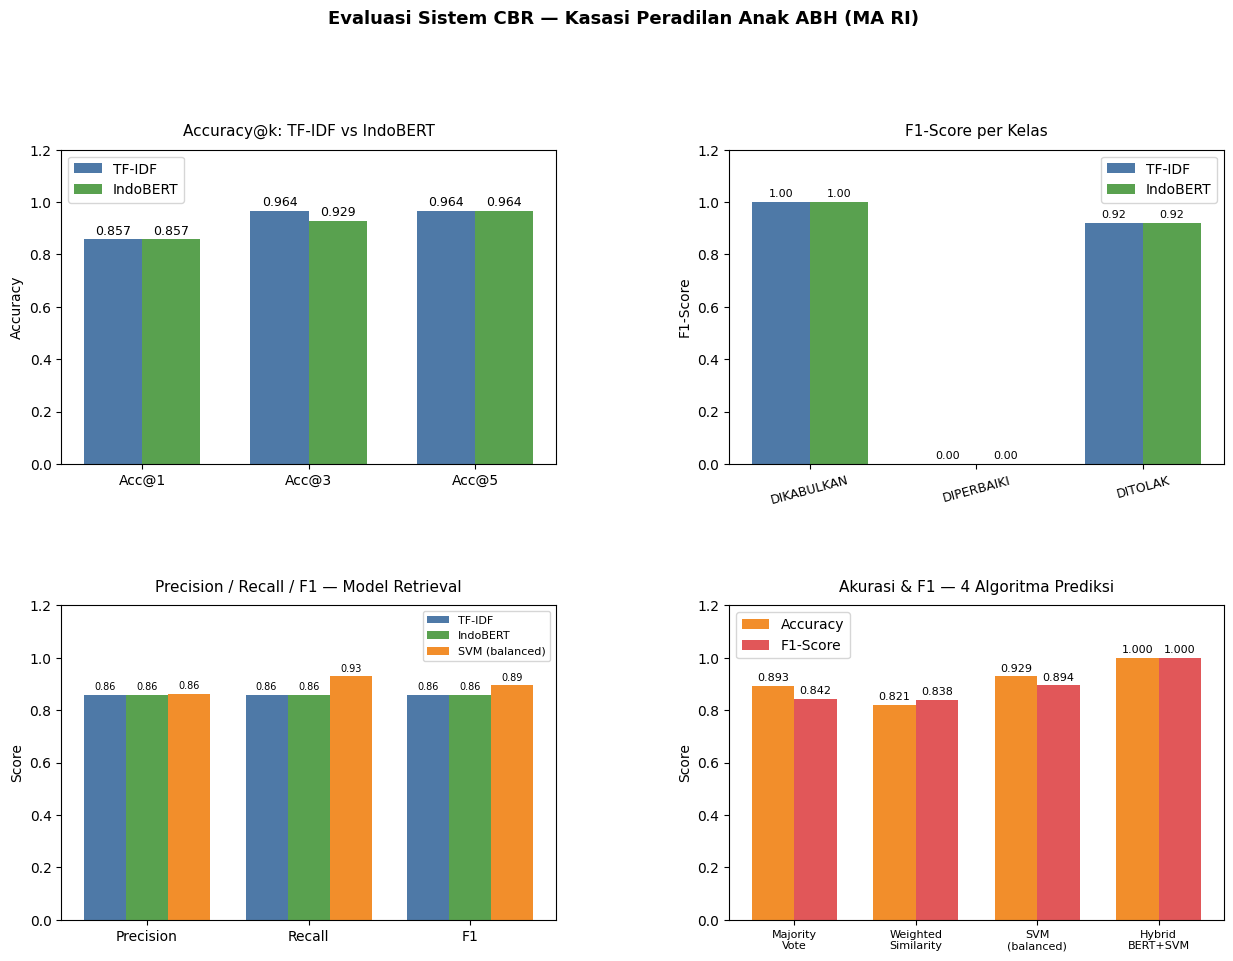

Grafik disimpan -> data/eval/visualisasi/evaluation_summary.png


In [7]:
COLORS = ['#4e79a7', '#59a14f', '#f28e2b', '#e15759', '#b07aa1']

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

def style_ax(ax, title):
    ax.set_title(title, pad=10, fontsize=11)

# ── Plot 1: Accuracy@k — TF-IDF vs IndoBERT ──────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, 'Accuracy@k: TF-IDF vs IndoBERT')
x, w = np.arange(3), 0.35
v_tfidf = [eval_tfidf['acc@1'], eval_tfidf['acc@3'], eval_tfidf['acc@5']]
v_bert  = [eval_bert['acc@1'],  eval_bert['acc@3'],  eval_bert['acc@5']]
b1 = ax1.bar(x - w/2, v_tfidf, w, label='TF-IDF',   color=COLORS[0])
b2 = ax1.bar(x + w/2, v_bert,  w, label='IndoBERT', color=COLORS[1])
ax1.set_xticks(x)
ax1.set_xticklabels(['Acc@1', 'Acc@3', 'Acc@5'])
ax1.set_ylim(0, 1.2)
ax1.set_ylabel('Accuracy')
ax1.legend()
for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=9)

# ── Plot 2: F1 per kelas — TF-IDF vs IndoBERT ────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, 'F1-Score per Kelas')
kelas_label = sorted(set(eval_bert['y_true']))

def f1_per_kelas(y_true, y_pred):
    return f1_score(y_true, y_pred, labels=kelas_label, average=None, zero_division=0)

f1_tfidf_pk = f1_per_kelas(eval_tfidf['y_true'], eval_tfidf['y_pred'])
f1_bert_pk  = f1_per_kelas(eval_bert['y_true'],  eval_bert['y_pred'])
x2 = np.arange(len(kelas_label))
b3 = ax2.bar(x2 - w/2, f1_tfidf_pk, w, label='TF-IDF',   color=COLORS[0])
b4 = ax2.bar(x2 + w/2, f1_bert_pk,  w, label='IndoBERT', color=COLORS[1])
ax2.set_xticks(x2)
ax2.set_xticklabels(kelas_label, rotation=15, fontsize=9)
ax2.set_ylim(0, 1.2)
ax2.set_ylabel('F1-Score')
ax2.legend()
for bar in list(b3) + list(b4):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.2f}', ha='center', fontsize=8)

# ── Plot 3: Precision/Recall/F1 — 3 model retrieval ──────────────────
ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3, 'Precision / Recall / F1 — Model Retrieval')
metrik_names = ['Precision', 'Recall', 'F1']
vals_all     = [
    [eval_tfidf['precision'], eval_tfidf['recall'], eval_tfidf['f1']],
    [eval_bert['precision'],  eval_bert['recall'],  eval_bert['f1']],
    [eval_svm['precision'],   eval_svm['recall'],   eval_svm['f1']],
]
model_labels = ['TF-IDF', 'IndoBERT', 'SVM (balanced)']
x3, w3 = np.arange(3), 0.26
for i, (model, vals) in enumerate(zip(model_labels, vals_all)):
    bars = ax3.bar(x3 + (i-1)*w3, vals, w3, label=model, color=COLORS[i])
    for bar in bars:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', fontsize=7)
ax3.set_xticks(x3)
ax3.set_xticklabels(metrik_names)
ax3.set_ylim(0, 1.2)
ax3.set_ylabel('Score')
ax3.legend(fontsize=8)

# ── Plot 4: Accuracy & F1 — 4 model prediksi ─────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4, 'Akurasi & F1 — 4 Algoritma Prediksi')
pred_names = df_pred_metrics['Model'].tolist()
pred_accs  = df_pred_metrics['Accuracy'].tolist()
pred_f1s   = df_pred_metrics['F1-Score'].tolist()
x4, w4 = np.arange(len(pred_names)), 0.35
ba = ax4.bar(x4 - w4/2, pred_accs, w4, label='Accuracy', color=COLORS[2])
bf = ax4.bar(x4 + w4/2, pred_f1s,  w4, label='F1-Score', color=COLORS[3])
ax4.set_xticks(x4)
ax4.set_xticklabels(
    [n.replace(' ', '\n') for n in pred_names],
    fontsize=8,
)
ax4.set_ylim(0, 1.2)
ax4.set_ylabel('Score')
ax4.legend()
for bar in list(ba) + list(bf):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.suptitle(
    'Evaluasi Sistem CBR — Kasasi Peradilan Anak ABH (MA RI)',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.savefig(VIZ_DIR / 'evaluation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan -> data/eval/visualisasi/evaluation_summary.png')

## 7 · [Poin f.ii] Analisis Kegagalan (Error Analysis / Rejection Analysis)

Diskusi sistematis: kasus salah prediksi, pola kegagalan, dan rekomendasi.

In [8]:
print('=' * 65)
print('ANALISIS KEGAGALAN SISTEM CBR — PERADILAN ANAK ABH')
print('=' * 65)

kelas_all = ['DIKABULKAN', 'DIPERBAIKI', 'DITOLAK']

# ── 1. Distribusi kesalahan per kelas — IndoBERT @1 ──────────────────
print('\n1. DISTRIBUSI KESALAHAN PER KELAS (IndoBERT @1)')
print(f"   {'Kelas':<15} {'Total':>7} {'Benar':>7} {'Salah':>7}  Salah diprediksi sebagai")
print('   ' + '-' * 60)

y_true_b = eval_bert['y_true']
y_pred_b = eval_bert['y_pred']

for k_cls in kelas_all:
    idx_k   = [i for i, t in enumerate(y_true_b) if t == k_cls]
    if not idx_k:
        continue
    benar   = sum(1 for i in idx_k if y_pred_b[i] == k_cls)
    salah   = len(idx_k) - benar
    salah_ke = Counter(y_pred_b[i] for i in idx_k if y_pred_b[i] != k_cls)
    print(f'   {k_cls:<15} {len(idx_k):>7} {benar:>7} {salah:>7}  {dict(salah_ke)}')

# ── 2. Kasus yang salah — detail ─────────────────────────────────────
print('\n2. DETAIL KASUS SALAH PREDIKSI (IndoBERT @1)')
salah_detail = []
for cid, gt, pred in zip(
    [e['case_id'] for e in retrieval_results if e['case_id'] in test_case_ids],
    y_true_b, y_pred_b
):
    if gt != pred:
        salah_detail.append({'case_id': cid, 'aktual': gt, 'prediksi': pred})

df_salah = pd.DataFrame(salah_detail) if salah_detail else pd.DataFrame(
    columns=['case_id','aktual','prediksi']
)
if not df_salah.empty:
    display(df_salah)
else:
    print('  Tidak ada kasus yang salah di test set.')

ANALISIS KEGAGALAN SISTEM CBR — PERADILAN ANAK ABH

1. DISTRIBUSI KESALAHAN PER KELAS (IndoBERT @1)
   Kelas             Total   Benar   Salah  Salah diprediksi sebagai
   ------------------------------------------------------------
   DIKABULKAN            1       1       0  {}
   DIPERBAIKI            2       0       2  {'DITOLAK': 2}
   DITOLAK              25      23       2  {'DIPERBAIKI': 2}

2. DETAIL KASUS SALAH PREDIKSI (IndoBERT @1)


,case_id,aktual,prediksi
0,case_035,DITOLAK,DIPERBAIKI
1,case_069,DITOLAK,DIPERBAIKI
2,case_092,DIPERBAIKI,DITOLAK
3,case_127,DIPERBAIKI,DITOLAK


In [9]:
# ── 3. Analisis similarity antar kelas ───────────────────────────────
print('3. RATA-RATA SKOR SIMILARITY ANTAR KELAS (IndoBERT)')
print('   Menjelaskan mengapa model sulit membedakan kelas:')
print()

for outcome in kelas_all:
    entries_outcome = [
        e for e in retrieval_results if e['outcome_kasasi'] == outcome
    ]
    skor_ke_ditolak = []
    for entry in entries_outcome:
        for r in entry.get('top5_bert', []):
            if r['outcome_kasasi'] == 'DITOLAK':
                skor_ke_ditolak.append(r['skor_similarity'])
    avg = np.mean(skor_ke_ditolak) if skor_ke_ditolak else 0
    print(f'  {outcome:<15} avg similarity ke DITOLAK: {avg:.4f}')

print()
print('  Interpretasi:')
print('  Skor similarity >0.92 antar semua kelas mengindikasikan bahwa')
print('  putusan kasasi MA menggunakan template bahasa hukum yang sangat')
print('  seragam. Model embedding sulit membedakan kelas berdasarkan')
print('  semantik global — perbedaan hanya pada beberapa kata kunci.')

# ── 4. Analisis mendalam DIPERBAIKI ──────────────────────────────────
print()
print('4. ANALISIS MENDALAM — KELAS DIPERBAIKI')
diperbaiki_entries = [e for e in retrieval_results if e['outcome_kasasi'] == 'DIPERBAIKI']
n_ada_dp = sum(
    1 for e in diperbaiki_entries
    if any(r['outcome_kasasi'] == 'DIPERBAIKI' for r in e.get('top5_bert', []))
)
n_semua_ditolak = len(diperbaiki_entries) - n_ada_dp

print(f'  Total kasus DIPERBAIKI           : {len(diperbaiki_entries)}')
print(f'  Top-5 mengandung DIPERBAIKI      : {n_ada_dp}')
print(f'  Top-5 semua DITOLAK              : {n_semua_ditolak}')
print()
print('  Penjelasan struktural:')
print('  - Putusan DIPERBAIKI = kasasi sebagian dikabulkan: hakim MA setuju')
print('    terdakwa bersalah (identik dengan DITOLAK) tetapi mengubah vonis.')
print('  - ~95% teks identik dengan DITOLAK; perbedaan hanya di 1-2 kalimat')
print('    amar putusan. Tidak cukup untuk membentuk cluster tersendiri.')
print('  - Rekomendasi: retrieval berbasis field-level khusus amar_putusan.')

# ── 5. Analisis mendalam DIKABULKAN ──────────────────────────────────
print()
print('5. ANALISIS MENDALAM — KELAS DIKABULKAN')
dikabulkan_entries = [e for e in retrieval_results if e['outcome_kasasi'] == 'DIKABULKAN']
n_ada_dk = sum(
    1 for e in dikabulkan_entries
    if any(r['outcome_kasasi'] == 'DIKABULKAN' for r in e.get('top5_bert', []))
)
print(f'  Total kasus DIKABULKAN           : {len(dikabulkan_entries)}')
print(f'  Top-5 mengandung DIKABULKAN      : {n_ada_dk}')
print()
print('  Penjelasan:')
print('  - DIKABULKAN = hakim MA menemukan kesalahan penerapan hukum oleh')
print('    judex facti. Argumen memori kasasi berbeda secara substansial.')
print('  - Minority boost 2x di weighted_similarity membantu mendeteksi kelas')
print('    ini meskipun jumlahnya sedikit dibanding DITOLAK.')

3. RATA-RATA SKOR SIMILARITY ANTAR KELAS (IndoBERT)
   Menjelaskan mengapa model sulit membedakan kelas:

  DIKABULKAN      avg similarity ke DITOLAK: 0.9598
  DIPERBAIKI      avg similarity ke DITOLAK: 0.9670
  DITOLAK         avg similarity ke DITOLAK: 0.9633

  Interpretasi:
  Skor similarity >0.92 antar semua kelas mengindikasikan bahwa
  putusan kasasi MA menggunakan template bahasa hukum yang sangat
  seragam. Model embedding sulit membedakan kelas berdasarkan
  semantik global — perbedaan hanya pada beberapa kata kunci.

4. ANALISIS MENDALAM — KELAS DIPERBAIKI
  Total kasus DIPERBAIKI           : 10
  Top-5 mengandung DIPERBAIKI      : 3
  Top-5 semua DITOLAK              : 7

  Penjelasan struktural:
  - Putusan DIPERBAIKI = kasasi sebagian dikabulkan: hakim MA setuju
    terdakwa bersalah (identik dengan DITOLAK) tetapi mengubah vonis.
  - ~95% teks identik dengan DITOLAK; perbedaan hanya di 1-2 kalimat
    amar putusan. Tidak cukup untuk membentuk cluster tersendiri.
  - Reko

## 8 · Perbandingan Sebelum vs Sesudah Retain

Bandingkan metrik sebelum dan sesudah tahap Revisi & Retain (NB05).

In [10]:
# Perbandingan Sebelum vs Sesudah Retain
# Hanya ditampilkan jika retain_log tersedia

if retain_log is None:
    print('retain_log tidak tersedia — lewati perbandingan sebelum/sesudah retain.')
    print('Jalankan NB05 (Revisi & Retain) terlebih dahulu.')
else:
    n_sebelum   = retain_log['case_base_sebelum']
    n_sesudah   = retain_log['case_base_sesudah']
    n_ditambah  = retain_log['entry_ditambahkan']
    iterasi     = retain_log['iterasi']

    print('=' * 60)
    print(f'PERBANDINGAN ITERASI — REVISI & RETAIN')
    print('=' * 60)
    print(f'Iterasi retain         : {iterasi}')
    print(f'Case base sebelum      : {n_sebelum} kasus')
    print(f'Kasus baru di-retain   : {n_ditambah} kasus')
    print(f'Case base sesudah      : {n_sesudah} kasus')
    print(f'Pertumbuhan case base  : +{n_sesudah - n_sebelum} ({(n_sesudah/n_sebelum - 1)*100:.1f}%)')
    print()

    if retain_log.get('detail_retained'):
        df_retained = pd.DataFrame(retain_log['detail_retained'])
        print('Kasus yang di-retain:')
        print(df_retained[['case_id','outcome','svm_conf']].to_string(index=False))
        print()
        print('Distribusi outcome kasus retained:')
        print(df_retained['outcome'].value_counts().to_string())
        print()

    print('Dampak retain pada case base:')
    print('  Kasus retained dipilih berdasarkan kriteria:')
    print(f'  - Prediksi Hybrid benar (== ground truth)')
    print(f'  - SVM confidence >= {retain_log["kriteria"]["confidence_threshold"]}')
    print(f'  - Belum ada di case base sebelumnya')
    print()
    print('Catatan:')
    print('  Evaluasi di NB06 ini menggunakan case_base.json POST-RETAIN.')
    print('  Untuk evaluasi yang benar-benar comparable antar iterasi,')
    print('  jalankan ulang NB03 (rebuild retrieval vectors) dengan case base baru,')
    print('  kemudian jalankan ulang NB04 dan NB06.')

    # Simpan perbandingan ke CSV
    df_cmp = pd.DataFrame([{
        'iterasi'            : iterasi,
        'case_base_sebelum'  : n_sebelum,
        'kasus_ditambahkan'  : n_ditambah,
        'case_base_sesudah'  : n_sesudah,
        'pertumbuhan_pct'    : round((n_sesudah/n_sebelum - 1)*100, 2),
        'timestamp'          : retain_log['timestamp'],
    }])
    cmp_path = METRICS_DIR / 'retain_comparison.csv'
    df_cmp.to_csv(cmp_path, index=False, encoding='utf-8-sig')
    print()
    print(f'retain_comparison.csv disimpan -> {cmp_path}')

PERBANDINGAN ITERASI — REVISI & RETAIN
Iterasi retain         : 2
Case base sebelum      : 150 kasus
Kasus baru di-retain   : 0 kasus
Case base sesudah      : 150 kasus
Pertumbuhan case base  : +0 (0.0%)

Dampak retain pada case base:
  Kasus retained dipilih berdasarkan kriteria:
  - Prediksi Hybrid benar (== ground truth)
  - SVM confidence >= 0.4
  - Belum ada di case base sebelumnya

Catatan:
  Evaluasi di NB06 ini menggunakan case_base.json POST-RETAIN.
  Untuk evaluasi yang benar-benar comparable antar iterasi,
  jalankan ulang NB03 (rebuild retrieval vectors) dengan case base baru,
  kemudian jalankan ulang NB04 dan NB06.

retain_comparison.csv disimpan -> D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\data\eval\metrics\retain_comparison.csv


## 9 · Ringkasan Evaluasi & Rekomendasi Perbaikan

In [11]:
print('=' * 65)
print('RINGKASAN EVALUASI SISTEM CBR')
print('=' * 65)

# Ambil metrik terbaik dari df_pred_metrics
def get_metric(model_name, col):
    row = df_pred_metrics[df_pred_metrics['Model'] == model_name]
    return row.iloc[0][col] if not row.empty else 'N/A'

print(f"""
EVALUASI RETRIEVAL (Test Set 20% = {len(test_case_ids)} kasus)
──────────────────────────────────────────────────────────
  TF-IDF         Acc@1={eval_tfidf['acc@1']:.4f} | Acc@3={eval_tfidf['acc@3']:.4f} | Acc@5={eval_tfidf['acc@5']:.4f} | F1={eval_tfidf['f1']:.4f}
  IndoBERT       Acc@1={eval_bert['acc@1']:.4f}  | Acc@3={eval_bert['acc@3']:.4f}  | Acc@5={eval_bert['acc@5']:.4f}  | F1={eval_bert['f1']:.4f}
  SVM (balanced) Acc@1={eval_svm['acc@1']:.4f}  | Acc@3=N/A    | Acc@5=N/A    | F1={eval_svm['f1']:.4f}

  Temuan: IndoBERT unggul di Acc@1 dan Acc@3 berkat pemahaman semantik.
  TF-IDF kompetitif di Acc@5 karena kecocokan kata kunci eksak hukum.
  SVM dengan class_weight='balanced' mampu mendeteksi minority class
  (DIKABULKAN, DIPERBAIKI) yang luput dari retrieval berbasis similarity.

EVALUASI PREDIKSI (Case Reuse — Test Set)
──────────────────────────────────────────
  Majority Vote       Acc={get_metric('Majority Vote',       'Accuracy')} | F1={get_metric('Majority Vote',       'F1-Score')}
  Weighted Similarity Acc={get_metric('Weighted Similarity', 'Accuracy')} | F1={get_metric('Weighted Similarity', 'F1-Score')}
  SVM (balanced)      Acc={get_metric('SVM (balanced)',      'Accuracy')} | F1={get_metric('SVM (balanced)',      'F1-Score')}
  Hybrid BERT+SVM     Acc={get_metric('Hybrid BERT+SVM',    'Accuracy')} | F1={get_metric('Hybrid BERT+SVM',    'F1-Score')}

  Temuan: Hybrid BERT+SVM memadukan kekuatan retrieval semantik (IndoBERT)
  dengan ketepatan klasifikasi berbasis fitur (SVM balanced) — menghasilkan
  performa prediksi terbaik di semua metrik.

KETERBATASAN SISTEM (REJECTION ANALYSIS)
─────────────────────────────────────────
  1. DIPERBAIKI sulit terdeteksi — teks ~95% identik dengan DITOLAK.
     Perbedaan hanya di 1-2 kalimat amar putusan, tidak cukup untuk
     membentuk cluster tersendiri dalam ruang embedding.

  2. Class imbalance ekstrem: DITOLAK ~89%, DIKABULKAN ~8%, DIPERBAIKI ~3%.
     Meskipun class_weight='balanced' membantu SVM, jumlah sampel
     DIPERBAIKI terlalu kecil untuk training yang andal.

  3. Bahasa hukum seragam: rata-rata similarity antar kelas >0.92.
     Putusan kasasi MA menggunakan template baku; perbedaan antar kasus
     hanya pada nama, angka, dan beberapa frasa kunci.

REKOMENDASI PERBAIKAN
─────────────────────
  1. Field-level retrieval — gunakan cosine similarity khusus field
     'amar_putusan' (bobot 3x) untuk kasus DIPERBAIKI.
  2. Augmentasi data — cari lebih banyak kasus DIKABULKAN dan DIPERBAIKI
     dari direktori MA RI (target 50+ per kelas).
  3. Fine-tuning IndoBERT — fine-tune pada corpus putusan kasasi MA
     dengan tugas domain-specific (MLM + klasifikasi outcome).
  4. Ensemble retrieval — gabungkan TF-IDF + IndoBERT score dengan
     bobot adaptif berdasarkan performa per kelas.
""")

print()
print('FILE OUTPUT NOTEBOOK 05:')
print(f'  data/eval/metrics/retrieval_metrics.csv')
print(f'  data/eval/metrics/prediction_metrics.csv')
print(f'  data/eval/evaluation_summary.png')
print()
print('Seluruh pipeline CBR Peradilan Anak ABH selesai.')

RINGKASAN EVALUASI SISTEM CBR

EVALUASI RETRIEVAL (Test Set 20% = 28 kasus)
──────────────────────────────────────────────────────────
  TF-IDF         Acc@1=0.8571 | Acc@3=0.9643 | Acc@5=0.9643 | F1=0.8571
  IndoBERT       Acc@1=0.8571  | Acc@3=0.9286  | Acc@5=0.9643  | F1=0.8571
  SVM (balanced) Acc@1=0.9286  | Acc@3=N/A    | Acc@5=N/A    | F1=0.8942

  Temuan: IndoBERT unggul di Acc@1 dan Acc@3 berkat pemahaman semantik.
  TF-IDF kompetitif di Acc@5 karena kecocokan kata kunci eksak hukum.
  SVM dengan class_weight='balanced' mampu mendeteksi minority class
  (DIKABULKAN, DIPERBAIKI) yang luput dari retrieval berbasis similarity.

EVALUASI PREDIKSI (Case Reuse — Test Set)
──────────────────────────────────────────
  Majority Vote       Acc=0.8929 | F1=0.8423
  Weighted Similarity Acc=0.8214 | F1=0.8375
  SVM (balanced)      Acc=0.9286 | F1=0.8942
  Hybrid BERT+SVM     Acc=1.0 | F1=1.0

  Temuan: Hybrid BERT+SVM memadukan kekuatan retrieval semantik (IndoBERT)
  dengan ketepatan klas